In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("Data/Processed/customer_churn_cleaned.csv")
df.head()

,customer_id,gender,age,tenure_months,contract_type,monthly_charges,payment_method,internet_service,support_tickets,complaints,avg_monthly_usage_gb,login_frequency,discount_percent,satisfaction_score,late_payments,total_charges,churn
0,CUST00001,Male,68,26,Two Year,1315.66,Debit Card,Unknown,2,2,310.00,30,20,1,1,27365.73,0
1,CUST00002,Female,64,48,One Year,4660.91,Credit Card,Fiber,3,1,226.32,9,15,8,0,190165.13,0
2,CUST00003,Male,64,19,Monthly,966.19,Debit Card,Fiber,1,2,67.11,13,15,6,0,15603.97,0
3,CUST00004,Male,21,9,Monthly,2943.45,UPI,Fiber,1,0,408.99,8,5,4,2,25166.50,0
4,CUST00005,Male,24,64,One Year,1913.04,Bank Transfer,Fiber,4,2,147.09,17,15,6,1,104069.38,0


In [4]:
print(df.shape)

(5000, 17)


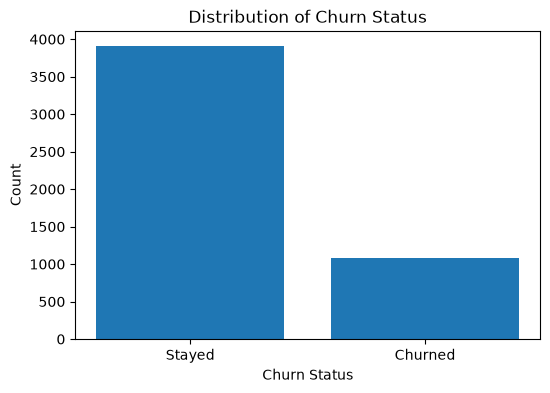

In [5]:
import matplotlib.pyplot as plt

churn_counts = df['churn'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(["Stayed", "Churned"], churn_counts.values)
plt.xlabel("Churn Status")
plt.ylabel("Count")
plt.title("Distribution of Churn Status")
plt.show()

In [6]:
df['churn'].value_counts(normalize=True)*100

churn
0    78.26
1    21.74
Name: proportion, dtype: float64

In [7]:
contract_churn = pd.crosstab(
    df['contract_type'], df['churn'], normalize="index"
) * 100

print(contract_churn)

churn                  0          1
contract_type                      
Monthly        72.262774  27.737226
One Year       86.682616  13.317384
Two Year       84.095427  15.904573


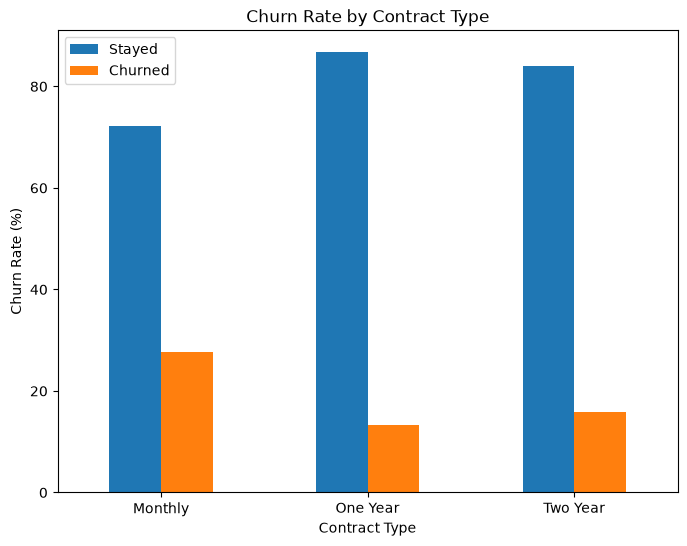

In [8]:
contract_churn.plot(kind='bar', figsize=(8, 6))

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)  
plt.legend(["Stayed", "Churned"])
plt.show()

In [9]:
satisfaction_churn = df.groupby(
    "satisfaction_score"
)["churn"].mean() * 100

print(satisfaction_churn)

satisfaction_score
1     40.192308
2     30.588235
3     30.384615
4     25.161290
5     24.497992
6     16.829746
7     15.019011
8     14.285714
9     10.245902
10     8.296943
Name: churn, dtype: float64


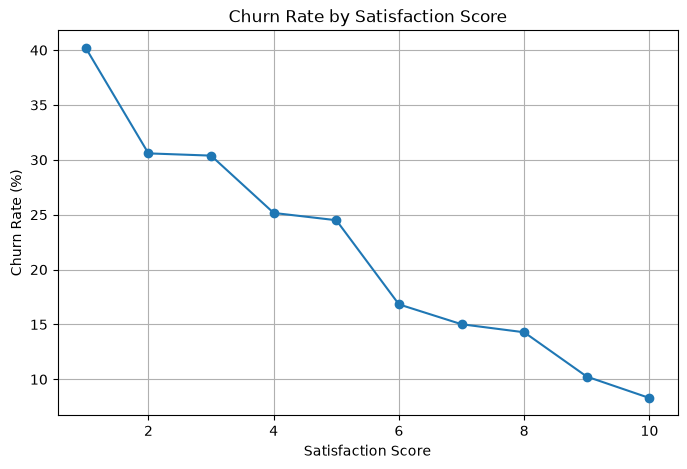

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    satisfaction_churn.index, satisfaction_churn.values, marker='o'
)

plt.title("Churn Rate by Satisfaction Score")
plt.xlabel("Satisfaction Score")
plt.ylabel("Churn Rate (%)")
plt.grid(True)
plt.show()

In [12]:
df["tenure_group"] = pd.cut(
    df["tenure_months"], bins=[0, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"])

In [14]:
tenure_churn = df.groupby(
    "tenure_group", observed=True
    )["churn"].mean() * 100

print(tenure_churn)

tenure_group
0-12 months     35.214724
13-24 months    27.985948
25-48 months    20.700060
49-72 months    13.022700
Name: churn, dtype: float64


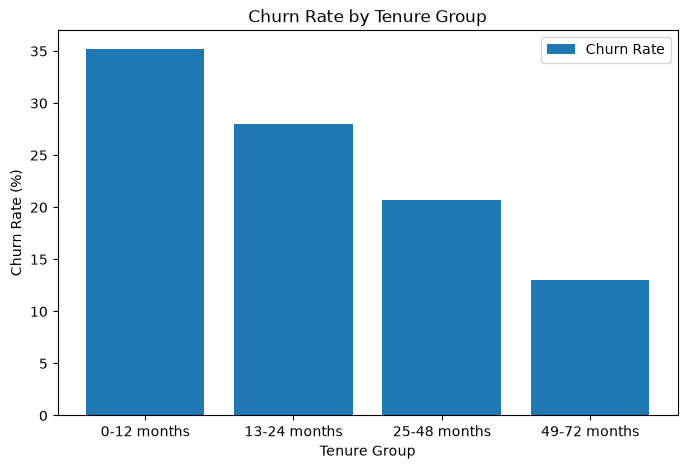

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    tenure_churn.index.astype(str),
    tenure_churn.values
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.legend(["Churn Rate"])
plt.show()

In [16]:
support_churn = df.groupby(
    "support_tickets"
)["churn"].mean() * 100

print(support_churn)

support_tickets
0     18.890555
1     21.223022
2     20.418848
3     22.158439
4     27.078891
5     25.806452
6     30.645161
7     25.000000
8     75.000000
9      0.000000
10     0.000000
Name: churn, dtype: float64


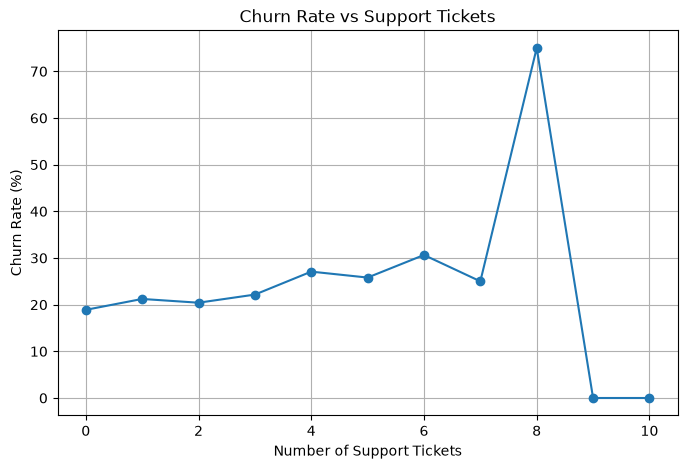

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    support_churn.index,
    support_churn.values,
    marker="o"
)

plt.title("Churn Rate vs Support Tickets")
plt.xlabel("Number of Support Tickets")
plt.ylabel("Churn Rate (%)")
plt.grid(True)
plt.show()

In [19]:
df["monthly_spend_after_discount"] = (
    df["monthly_charges"] *
    (1 - df["discount_percent"] / 100)
)

In [21]:
df["support_burden"] = (
    df["support_tickets"] +
    df["complaints"]
)

df["payment_risk"] = (
    df["late_payments"] +
    df["complaints"]
)

df["engagement_level"] = pd.cut(
    df["login_frequency"],
    bins=[0, 10, 20, 30],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

df["satisfaction_level"] = pd.cut(
    df["satisfaction_score"],
    bins=[0, 3, 7, 10],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

In [22]:
df[
    [
        "customer_id",
        "monthly_charges",
        "discount_percent",
        "monthly_spend_after_discount",
        "support_tickets",
        "complaints",
        "support_burden",
        "late_payments",
        "payment_risk",
        "login_frequency",
        "engagement_level",
        "satisfaction_score",
        "satisfaction_level",
        "churn"
    ]
].head(10)

,customer_id,monthly_charges,discount_percent,monthly_spend_after_discount,support_tickets,complaints,support_burden,late_payments,payment_risk,login_frequency,engagement_level,satisfaction_score,satisfaction_level,churn
0,CUST00001,1315.66,20,1052.5280,2,2,4,1,3,30,High,1,Low,0
1,CUST00002,4660.91,15,3961.7735,3,1,4,0,1,9,Low,8,High,0
2,CUST00003,966.19,15,821.2615,1,2,3,0,2,13,Medium,6,Medium,0
3,CUST00004,2943.45,5,2796.2775,1,0,1,2,2,8,Low,4,Medium,0
4,CUST00005,1913.04,15,1626.0840,4,2,6,1,3,17,Medium,6,Medium,0
5,CUST00006,1721.37,10,1549.2330,3,1,4,2,3,16,Medium,2,Low,0
6,CUST00007,3406.26,0,3406.2600,2,2,4,3,5,25,High,4,Medium,0
7,CUST00008,1540.57,0,1540.5700,1,1,2,0,1,16,Medium,8,High,0
8,CUST00009,4623.64,5,4392.4580,2,1,3,1,2,21,High,4,Medium,1
9,CUST00010,2327.20,20,1861.7600,2,1,3,2,3,30,High,5,Medium,0


In [23]:
import os

os.makedirs("Data/Processed", exist_ok=True)

df.to_csv(
    "Data/Processed/customer_churn_feature_engineered.csv",
    index=False
)

print("Feature-engineered dataset saved!")

Feature-engineered dataset saved!
